# BLS signal: Green functions, pupil fields (GF#2)
This example shows how SpinWaveToolkit (SWT) can be used to calculate the expected BLS signal of a single magnetic layer using the Green's function formalism and laser electric fields in reciprocal space.

The only difference to the example [GF#1](BLS_signal_from_GF_focal.ipynb) is the input field: here, the incident field is given directly in reciprocal space by `ObjectiveLens.getPupilField()`, on the same k-space grid as the magneto-optical susceptibility.  The Fourier transform of the focal field and its interpolation onto the k-space grid are therefore not needed, and the field is not affected by the finite real-space window of the focal field.  Otherwise, `get_signal_GF_pupil()` and `get_signal_GF_focal()` perform the same calculation.

Related examples: [GF#1](BLS_signal_from_GF_focal.ipynb) (Green functions, focal fields), [RT#1](BLS_signal_from_RT_focal.ipynb) (reciprocity theorem, focal fields), [RT#2](BLS_signal_from_RT_pupil.ipynb) (reciprocity theorem, pupil fields), [comparison of all methods](BLS_signal_comparison.ipynb).

Source publication: Wojewoda et al., *Physical Review B* **110**, 224428 (2024). DOI: [10.1103/PhysRevB.110.224428](https://doi.org/10.1103/PhysRevB.110.224428)

### 1. Import modules and define parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import SpinWaveToolkit as SWT

In [2]:
# Magnetic layer
Bext = 50e-3            # (T) external field
theta = np.pi / 2       # (rad) out-of-plane angle of magnetization (in-plane)
phi0 = np.pi / 2        # (rad) in-plane angle of magnetization wrt. x axis
d_layer = 30e-9         # (m) layer thickness
material = SWT.NiFe     # material (from built-ins)
Nf_common = 101         # number of frequency points
fmin, fmax = 4e9, 27e9  # (Hz) frequency range

# Optics
NA = 0.75               # numerical aperture of the objective
wavelength = 532e-9     # (m)

# k-space grid: it must be symmetric and equidistant, preferably with an odd number
# of points (k = 0 on the grid), and should reach 2*k0*NA (here 17.7 rad/um), since
# magnons with such wavevectors can still scatter light into the objective.
k_max = 18e6            # (rad/m) maximum k
Nk = 101                # resolution in Kx and Ky (odd)

### 2. Calculate the dynamic susceptibility

The magneto-optical susceptibility tensor is constructed from the spin-wave Bloch functions of the two lowest modes (n = 0, 1).  The static magnetization is along *y*, so the dynamic components are `mx` and `mz`.  Here we use only the linear magneto-optical response (`mo_linear()`), but any susceptibility tensor can be used, e.g. including the quadratic magneto-optical effects (see the documentation of the `susceptibilities` submodule).

The Bloch functions are calculated for all wavevectors at once by passing flattened arrays of wavenumbers and propagation angles to the dispersion model, which is much faster than calculating them point by point.  This is currently supported only by the `SingleLayer` and `SingleLayerNumeric` classes.  For the other dispersion classes, calculate the Bloch functions for each point of the k-space grid in a loop, as shown in the example [GF#1](BLS_signal_from_GF_focal.ipynb).

In [3]:
# k-space grid
kx_grid = np.linspace(-k_max, k_max, Nk)
ky_grid = np.linspace(-k_max, k_max, Nk)
KX, KY = np.meshgrid(kx_grid, ky_grid, indexing="ij")

# k-magnitude and propagation angle (angle between k and magnetization)
kxi = np.sqrt(KX**2 + KY**2)
kxi[kxi < 1e-6] = 1e-6  # avoid k = 0 in the dispersion model
phi = SWT.wrapAngle(np.arctan2(KY, KX) + phi0)

w_common = np.linspace(2 * np.pi * fmin, 2 * np.pi * fmax, Nf_common)  # common frequency axis

# Create a SingleLayer model for all grid points at once.
# Note: We pass kxi and phi as flattened arrays of same shape.
model = SWT.SingleLayer(Bext=Bext, kxi=kxi.flatten(), theta=theta,
                        phi=phi.flatten(), d=d_layer, material=material)
Bloch2D = np.zeros((Nf_common, Nk, Nk))
for n in (0, 1):  # higher n are outside `w_common`
    # The returned w has shape (Nf,) and is common for all wavevectors, bf has shape
    # (Nf, Nk*Nk).  Since w spans the frequencies of all wavevectors, more points
    # are needed to sample the narrow Bloch functions (here 10 times more).
    # We pass also parameters for Bose-Einstein distribution (optional).
    w, bf = model.GetBlochFunction(n=n, Nf=10 * Nf_common, temp=300, mu=-1e12 * SWT.H)
    # Interpolate to the common frequency axis (for all wavevectors at once)
    # and reshape to the Kx,Ky grid.
    bf = interp1d(w, bf, axis=0, bounds_error=False, fill_value=0)(w_common)
    Bloch2D += bf.reshape((Nf_common, Nk, Nk))

# Dynamic magnetization and the linear magneto-optical susceptibility tensor
mx, my, mz = Bloch2D, np.zeros_like(Bloch2D), -1j * Bloch2D
chi = SWT.bls.susceptibilities.mo_linear([mx, my, mz])

### 3. Prepare the incident field

The incident field is calculated directly on the k-space grid of the susceptibility.  The beam is linearly polarized along *x* in the entrance pupil of the objective.  (`getPupilField()` returns the angular spectrum of the focal field, which `get_signal_GF_pupil()` converts to the Fourier transform internally.)

In [4]:
objective = SWT.bls.ObjectiveLens(NA=NA, wavelength=wavelength, f0=10, f=1e-3)
Ei = objective.getPupilField(z=0, KX=KX, KY=KY, pol_type="linear", pol_angle=0)

### 4. Calculate the BLS signal

The light scattered by the magnetic layer is propagated through the multilayer stack (air, NiFe, substrate) to the objective.  Since the incident field is polarized along *x* and only the linear MO response is assumed, the maximum BLS signal is expected with the output analyzer rotated by 90° (along *y*).

C:\Users\228634\AppData\Local\Temp\ipykernel_5796\2108261453.py:12: UserWarning: `get_signal_GF_pupil` is an experimental function and may be subject to change. Please verify results carefully.
  sigma = SWT.bls.get_signal_GF_pupil(


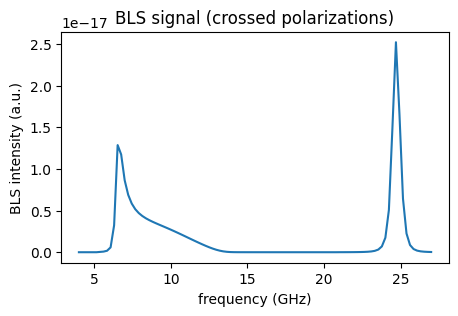

In [5]:
gf_params = dict(
    # dielectric functions of the multilayer system: air, NiFe, substrate
    DF=[1, -8.1653 + 1j * 15.348, 17.237 + 1j * 0.43004],
    PM=[1, 1, 1],  # same for permeabilities (response of NiFe is included in the susceptibility)
    d=[d_layer],   # thicknesses of the inner layers, here just NiFe
    NA=NA,         # numerical aperture of the collecting objective (here the same as focusing)
    source_layer_index=1,  # layer with the magnetic film
    output_layer_index=0,  # layer in which we observe the scattered light (air)
    # other parameters of the optical setup
    wavelength=wavelength, collectionSpot=0.5e-6, focalLength=1e-3,
)
sigma = SWT.bls.get_signal_GF_pupil(
    KxKy=[kx_grid, ky_grid],  # common k-space grid of the field and the susceptibility
    Ei_fields=Ei,             # incident field in reciprocal space
    Chi=chi,                  # susceptibility tensor with shape (3, 3, Nf, Nkx, Nky)
    output_analyzer="linear", output_analyzer_angle_deg=90,
    **gf_params,
)

f_GHz = w_common / (2 * np.pi * 1e9)
plt.figure(figsize=(5, 3))
plt.plot(f_GHz, sigma)
plt.xlabel("frequency (GHz)")
plt.ylabel("BLS intensity (a.u.)")
plt.title("BLS signal (crossed polarizations)")
plt.show()

*(Note: Sometimes the relative amplitude of PSSW peaks does not match the experiment, since it may depend on a vast number of parameters. If that is the case, calculate the BLS signal separately and normalize to each respective peak.)*

### 5. Polarization of the incident beam and of the detection

The polarization of the incident beam can be any polarization type of `getPupilField()` or a (spatially varying) Jones vector, e.g. prepared with the `bls.polarization` submodule (wave plates, spiral phase plates, q-plates, ...).  The output analyzer accepts the same polarization types.  As an example, we compare the crossed linear polarizations from above with parallel ones and with circular polarizations (right-handed incident beam, right- or left-handed analyzer).

C:\Users\228634\AppData\Local\Temp\ipykernel_5796\1183864676.py:4: UserWarning: `get_signal_GF_pupil` is an experimental function and may be subject to change. Please verify results carefully.
  "x in, x analyzer (parallel)": SWT.bls.get_signal_GF_pupil(


C:\Users\228634\AppData\Local\Temp\ipykernel_5796\1183864676.py:7: UserWarning: `get_signal_GF_pupil` is an experimental function and may be subject to change. Please verify results carefully.
  "rcp in, rcp analyzer": SWT.bls.get_signal_GF_pupil(


C:\Users\228634\AppData\Local\Temp\ipykernel_5796\1183864676.py:9: UserWarning: `get_signal_GF_pupil` is an experimental function and may be subject to change. Please verify results carefully.
  "rcp in, lcp analyzer": SWT.bls.get_signal_GF_pupil(


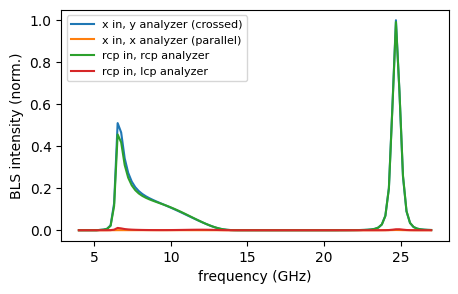

In [6]:
Ei_rcp = objective.getPupilField(z=0, KX=KX, KY=KY, pol_type="rcp")
signals = {
    "x in, y analyzer (crossed)": sigma,
    "x in, x analyzer (parallel)": SWT.bls.get_signal_GF_pupil(
        [kx_grid, ky_grid], Ei, chi, output_analyzer="linear",
        output_analyzer_angle_deg=0, **gf_params),
    "rcp in, rcp analyzer": SWT.bls.get_signal_GF_pupil(
        [kx_grid, ky_grid], Ei_rcp, chi, output_analyzer="rcp", **gf_params),
    "rcp in, lcp analyzer": SWT.bls.get_signal_GF_pupil(
        [kx_grid, ky_grid], Ei_rcp, chi, output_analyzer="lcp", **gf_params),
}

plt.figure(figsize=(5, 3))
for label, s in signals.items():
    plt.plot(f_GHz, s / sigma.max(), label=label)
plt.xlabel("frequency (GHz)")
plt.ylabel("BLS intensity (norm.)")
plt.legend(fontsize=8)
plt.show()

With parallel polarizations, the scattered light is mostly blocked by the analyzer, since the linear MO effect rotates the polarization of the scattered light by 90°.  For a circularly polarized incident beam, the linear MO effect (rotation of the field by 90° around *z*) keeps the handedness, so the scattered light passes the analyzer of the same handedness and is blocked by the opposite one.  With the same handedness, the signal is about the same as with the crossed linear polarizations.